In [1]:
import os
import torch
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from earth2studio.models.dx import TCTrackerWuDuan, TCTrackerVitart
from datetime import datetime, timedelta
from earth2studio.data import prep_data_array
from earth2studio.utils.coords import map_coords
from earth2studio.data import WB2ERA5
#import tropycal.tracks as tracks
import matplotlib.patches as mpatches
import glob
import warnings

/glade/work/turuncu/ML/envs/earth2studio/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/glade/work/turuncu/ML/envs/earth2studio/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


In [2]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Analyses for Hurricane Irene

Hurricane Irene was a large and powerful Atlantic hurricane that left extensive flood and wind damage along its path through the Caribbean, the United States East Coast and as far north as Canada. Irene made landfall near Cape Lookout, North Carolina at around 7:30 AM EDT on August 27, 2011 as a strong category 1 storm.

**More information:**

https://www.nhc.noaa.gov/data/tcr/AL092011_Irene.pdf

https://www.weather.gov/mhx/aug272011eventreview

https://www.weather.gov/gyx/Irene_Anniversary

### Storm Track Analysis

Calculate tracks for Aurora predictions. In here we are triggering tracking algorithm every 6-hour starting from 2011-08-21T00:00:00 to 2011-08-30T00:00:00. The number of steps used in the tracker is the actual distance to 2011-08-30T00:00:00 for each prediction. So, the number of steps is decreasing along with going forward in the prediction.

In [3]:
# Arguments
start_date = "2011-08-21T00:00:00"
start_date = datetime.strptime(start_date, "%Y-%m-%dT%H:%M:%S")
end_date = "2011-08-30T00:00:00"
end_date=datetime.strptime(end_date, "%Y-%m-%dT%H:%M:%S")
time_delta = 6
time_range = pd.date_range(start_date, end_date, freq=f"{time_delta}h").strftime('%Y-%m-%dT%H:%M:%S').to_list()
print(len(time_range))

# Path for Aurora predictions
data_path = "/glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene/"

37


In [39]:
# Init tracker
tracker = TCTrackerWuDuan(path_search_distance=450, path_search_window_size=2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
tracker = tracker.to(device)
tracker.reset_path_buffer()

In [2]:
# Loop over times
for t in time_range:
    tracker.reset_path_buffer()
    # Load dataset and make compatible with TCTrackerWuDuan
    print(f'Load {os.path.join(data_path, f"pred_{t}.nc")}')
    ds_aurora = xr.open_dataset(os.path.join(data_path, f"pred_{t}.nc"))
    ds_track = xr.merge(
        [
            ds_aurora[['10u', '10v', 'msl']].rename({'10u': 'u10m', '10v': 'v10m'}), 
            ds_aurora[['u','v','z']].sel(level=850).rename({'u': 'u850', 'v': 'v850', 'z': 'z850'}).drop_vars(["level"]),
            ds_aurora[['z','t']].sel(level=500).rename({'z': 'z500', 't': 't500'}).drop_vars(["level"]),
            ds_aurora[['t']].sel(level=400).rename({'t': 't400'}).drop_vars(["level"]),
            ds_aurora[['t']].sel(level=300).rename({'t': 't300'}).drop_vars(["level"]),
            ds_aurora[['t']].sel(level=250).rename({'t': 't250'}).drop_vars(["level"]),
            ds_aurora[['z','t']].sel(level=200).rename({'z': 'z200', 't': 't200'}).drop_vars(["level"]),
        ]
    ).drop_vars(['rollout_step'])
    ds_track['time'] = ds_track['time']-ds_track['time'].isel(time=0)
    ds_track = ds_track.rename({'time': 'lead_time', 'latitude': 'lat', 'longitude': 'lon'})
    ds_track = ds_track.rename({'batch': 'time'})
    ds_track['time'] = [datetime.strptime(t, "%Y-%m-%dT%H:%M:%S")]

    # Track hurricane
    nsteps = int((end_date-datetime.strptime(t, "%Y-%m-%dT%H:%M:%S"))/ timedelta(hours=time_delta))
    start_time = datetime.strptime(t, "%Y-%m-%dT%H:%M:%S")
    times = [start_time + timedelta(hours=6 * i) for i in range(nsteps + 1)]
    td = [t-times[0] for t in times]
    for step in range(0,len(td)-1):
        lead_time = np.timedelta64(td[step], 'ns')
        da = ds_track[tracker.input_coords()["variable"]].sel(lead_time=lead_time).to_array(dim='variable').T.transpose("time", "variable", "lat", "lon")
        x, coords = prep_data_array(da, device=device)
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, output_coords = tracker(x, coords)
        print(f"Step {step}: GraphCast tracks output shape {output.shape}")

    # Save tracks
    model_tracks = output.cpu()
    torch.save(model_tracks, f"irene_model_paths_{t}_{nsteps}.pt")

Load /glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene/pred_2011-08-21T00:00:00.nc
Step 0: GraphCast tracks output shape torch.Size([1, 4, 1, 4])
Step 1: GraphCast tracks output shape torch.Size([1, 4, 2, 4])
Step 2: GraphCast tracks output shape torch.Size([1, 5, 3, 4])
Step 3: GraphCast tracks output shape torch.Size([1, 6, 4, 4])
Step 4: GraphCast tracks output shape torch.Size([1, 7, 5, 4])
Step 5: GraphCast tracks output shape torch.Size([1, 8, 6, 4])
Step 6: GraphCast tracks output shape torch.Size([1, 8, 7, 4])
Step 7: GraphCast tracks output shape torch.Size([1, 9, 8, 4])
Step 8: GraphCast tracks output shape torch.Size([1, 10, 9, 4])
Step 9: GraphCast tracks output shape torch.Size([1, 10, 10, 4])
Step 10: GraphCast tracks output shape torch.Size([1, 11, 11, 4])
Step 11: GraphCast tracks output shape torch.Size([1, 11, 12, 4])
Step 12: GraphCast tracks output shape torch.Size([1, 12, 13, 4])
Step 13: GraphCast tracks output shape torch.Size([1, 13, 14, 4])
Step

Calculate storm track using ERA5 dataset

In [40]:
# Calculate tracks using ERA5
tracker.reset_path_buffer()
data = WB2ERA5(verbose=False)
nsteps = 36
times = [start_date + timedelta(hours=6 * i) for i in range(nsteps + 1)]
for step, time in enumerate(times):
    da = data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=device)
    output, output_coords = tracker(x, coords)
    print(f"Step {step}: ERA5 tracks output shape {output.shape}")

era5_tracks = output.cpu()
torch.save(era5_tracks, "irene_era5_paths.pt")

2025-12-15 11:48:24.087 | DEBUG    | earth2studio.data.wb2:fetch_array:253 - Fetching WB2 zarr array for variable: v10m at 2011-08-21T00:00:00
<class 'earth2studio.lexicon.wb2.WB2Lexicon'>
2025-12-15 11:48:24.088 | DEBUG    | earth2studio.data.wb2:fetch_array:253 - Fetching WB2 zarr array for variable: u10m at 2011-08-21T00:00:00
<class 'earth2studio.lexicon.wb2.WB2Lexicon'>
2025-12-15 11:48:24.088 | DEBUG    | earth2studio.data.wb2:fetch_array:253 - Fetching WB2 zarr array for variable: u850 at 2011-08-21T00:00:00
<class 'earth2studio.lexicon.wb2.WB2Lexicon'>
2025-12-15 11:48:24.088 | DEBUG    | earth2studio.data.wb2:fetch_array:253 - Fetching WB2 zarr array for variable: msl at 2011-08-21T00:00:00
<class 'earth2studio.lexicon.wb2.WB2Lexicon'>
2025-12-15 11:48:24.088 | DEBUG    | earth2studio.data.wb2:fetch_array:253 - Fetching WB2 zarr array for variable: v850 at 2011-08-21T00:00:00
<class 'earth2studio.lexicon.wb2.WB2Lexicon'>
Step 0: ERA5 tracks output shape torch.Size([1, 4, 1, 4]

In [5]:
# Get best track data
basin = tracks.TrackDataset(basin='north_atlantic', source='hurdat', include_btk=True)
storm = basin.get_storm(("irene", 2011))
storm

NameError: name 'tracks' is not defined

### Run Aurora provided tracking tool over previously generated predictions

In [60]:
from aurora import Tracker
from aurora import Batch, Metadata

# Loop over files
init_lat=15.0
init_lon=-59.0
files = sorted(glob.glob(os.path.join(data_path, "pred_*.nc")))
for f in files:
    # Load dataset
    ds_aurora = xr.open_dataset(f)

    # Debugging
    print(f"Load {f} - {ds_aurora.time.values[0]} - {init_lat}/{init_lon}")
    
    # Init tracker
    tracker = Tracker(init_lat=init_lat, init_lon=init_lon, init_time=ds_aurora.time.values[0])

    # Loop over time steps
    for t in ds_aurora.time.values:
        # Create batch
        data = ds_aurora.sel(time=t)    
        batch = Batch(
            surf_vars={
                "2t": torch.from_numpy(data["2t"].values[None]),
                "10u": torch.from_numpy(data["10u"].values[None]),
                "10v": torch.from_numpy(data["10v"].values[None]),
                "msl": torch.from_numpy(data["msl"].values[None]),
            },
            static_vars={
                # The static variables are constant, so we just get them for the first time. They
                # don't need to be flipped along the latitude dimension, because they are from
                # ERA5.
                "z": torch.from_numpy(data["z"].values),
                "slt": torch.from_numpy(data["slt"].values),
                "lsm": torch.from_numpy(data["lsm"].values),
            },
            atmos_vars={
                "t": torch.from_numpy(data["t"].values[None]),
                "u": torch.from_numpy(data["u"].values[None]),
                "v": torch.from_numpy(data["v"].values[None]),
                "q": torch.from_numpy(data["q"].values[None]),
                "z": torch.from_numpy(data["z"].values[None]),
            },
            metadata=Metadata(
                # Flip the latitudes! We need to copy because converting to PyTorch, because the
                # data must be contiguous.
                lat=torch.from_numpy(data.latitude.values),
                lon=torch.from_numpy(data.longitude.values),
                # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
                # `datetime.datetime`s. Note that this needs to be a tuple of length one:
                # one value for every batch element. Select the third time point.
                #time=(data.time.values.astype("datetime64[s]").tolist()[2],),
                time=(data.time.values,),
                atmos_levels=tuple(int(level) for level in data.level.values),
            ),
        )
        
        # Run tracker
        tracker.step(batch)
    
    # Store results
    ofile = f"track_{pd.to_datetime(ds_aurora.time.values[0]).strftime('%Y-%m-%dT%H:%M:%S')}.nc"
    if os.path.exists(ofile):
        os.remove(ofile)
    ds = xr.Dataset.from_dataframe(tracker.results())
    ds.to_netcdf(ofile)

    # Update init_lat and init_lon
    init_lat = ds.lat.values[1]
    init_lon = ds.lon.values[1]

Load /glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene/pred_2011-08-21T00:00:00.nc - 2011-08-21T00:00:00.000000000 - 15.0/-59.0


KeyError: "No variable named 'u10'. Did you mean one of ('10w', '10v', '10u')?"

### Run Aurora provided tracking tool using ERA5

In [ ]:
from aurora import Tracker
from aurora import Batch, Metadata

# Create dataset
era5_path = '/glade/derecho/scratch/turuncu/data/Data_aurora/split_files'
files = sorted(glob.glob(os.path.join(era5_path, "data_*.nc")))
ds = xr.open_mfdataset(files, data_vars="all", chunks='auto', engine="netcdf4").sel(time=time_range)
ds = ds.isel(latitude=slice(None, -1))

# Init tracker
init_lat=15.0
init_lon=-59.0
tracker = Tracker(init_lat=init_lat, init_lon=init_lon, init_time=ds.time.values[0])

# Loop over timesteps
for t in time_range:
    print(t)
    # Create batch
    batch = Batch(
        surf_vars={
            "2t": torch.from_numpy(ds["t2m"].values[None]),
            "10u": torch.from_numpy(ds["u10"].values[None]),
            "10v": torch.from_numpy(ds["v10"].values[None]),
            "msl": torch.from_numpy(ds["msl"].values[None]),
        },
        static_vars={
            # The static variables are constant, so we just get them for the first time. They
            # don't need to be flipped along the latitude dimension, because they are from
            # ERA5.
            "z": torch.from_numpy(ds["hgt"].values),
            "slt": torch.from_numpy(ds["slt"].values),
            "lsm": torch.from_numpy(ds["lsm"].values),
        },
        atmos_vars={
            "t": torch.from_numpy(ds["t"].values[None]),
            "u": torch.from_numpy(ds["u"].values[None]),
            "v": torch.from_numpy(ds["v"].values[None]),
            "q": torch.from_numpy(ds["q"].values[None]),
            "z": torch.from_numpy(ds["z"].values[None]),
        },
        metadata=Metadata(
            # Flip the latitudes! We need to copy because converting to PyTorch, because the
            # data must be contiguous.
            lat=torch.from_numpy(ds.latitude.values),
            lon=torch.from_numpy(ds.longitude.values),
            # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
            # `datetime.datetime`s. Note that this needs to be a tuple of length one:
            # one value for every batch element. Select the third time point.
            #time=(data.time.values.astype("datetime64[s]").tolist()[2],),
            time=(ds.time.values,),
            atmos_levels=tuple(int(level) for level in ds.level.values),
        ),
    )

    # Run tracker
    tracker.step(batch)
    
# Store results
ofile = "track_era5.nc"
if os.path.exists(ofile):
    os.remove(ofile)
ds = xr.Dataset.from_dataframe(tracker.results())    
ds.to_netcdf(ofile)

['t', 'u', 'v', 'q', 'z', 't2m', 'd2m', 'u10', 'v10', 'msl', 'sst', 'tcc', 'tp', 'ssr', 'str', 'ssrd', 'strd', 'hgt', 'lsm', 'slt', 'rh2', 'q2', 'w10', 'time', 'level', 'latitude', 'longitude']
2011-08-21T00:00:00
2011-08-21T06:00:00
2011-08-21T12:00:00
2011-08-21T18:00:00
2011-08-22T00:00:00
2011-08-22T06:00:00
2011-08-22T12:00:00
2011-08-22T18:00:00


### Create tracking plot

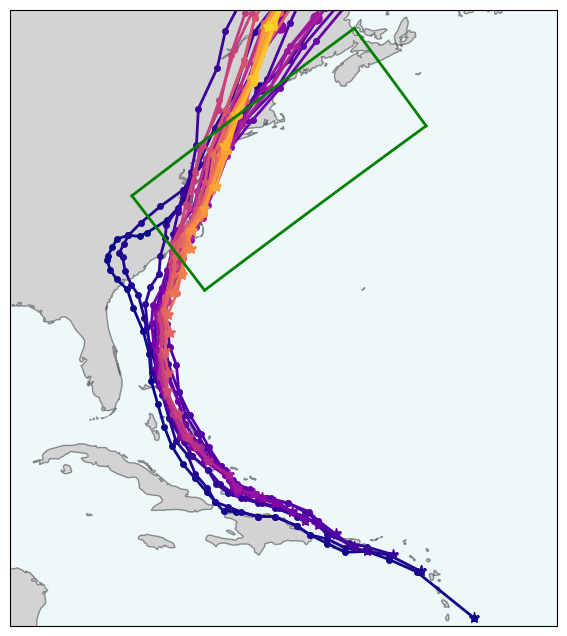

In [47]:
# Define bounding box limits
min_lat, max_lat = 13, 47
min_lon, max_lon = 275, 305

# Create figure with cartopy projection
plt.figure(figsize=(10, 8))
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)
ax = plt.axes(projection=projection)

# Add map features
ax.add_feature(cfeature.COASTLINE, alpha=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Plot Aurora
files = sorted(glob.glob("track_*.nc"))
colors = plt.get_cmap('plasma')(np.linspace(0, 1, len(files)-1))
id = 0
for f in files[1:]:
    ds = xr.open_dataset(f)
    if id == 0:
        lon_sum = ds.lon.values
        lat_sum = ds.lat.values
    else:
        lon_sum = lon_sum+ds.lon.values
        lat_sum = lat_sum+ds.lat.values
    ns = int((end_date-pd.to_datetime(ds.time.values[0]))/timedelta(hours=6))
    if ns == 0:
        continue
    ds = ds.isel(index=range(1, ns+1))
    color = id
    ax.plot(ds.lon.values[0],
            ds.lat.values[0],
            marker='*',
            linestyle='None',
            markersize=8,
            color=colors[id],
            transform=ccrs.PlateCarree()
    )
    ax.plot(
        ds.lon,
        ds.lat,
        color=colors[id],
        marker="o",
        markersize=4,
        linewidth=2,
        label="Aurora",
        transform=ccrs.PlateCarree(),
    )
    ax.plot(ds.lon.values[-1],
            ds.lat.values[-1],
            marker='o',
            linestyle='None',
            markersize=8,
            color=colors[id],
            transform=ccrs.PlateCarree()
    )
    id = id+1

# Calculate avarage path
lon_avg = lon_sum/len(files)-1
lat_avg = lat_sum/len(files)-1

# Plot Aurora average path ?


# Add legend
#best_patch = mpatches.Rectangle((0, 0), 1, 1, fc=best_cmap(0.3), alpha=0.9, label="Best Track")
#era5_patch = mpatches.Rectangle((0, 0), 1, 1, fc=era5_cmap(0.3), alpha=0.9, label="ERA5")
#model_patch = mpatches.Rectangle((0, 0), 1, 1, fc=model_cmap(0.3), alpha=0.9, label="Aurora")
#ax.legend(handles=[best_patch, era5_patch, model_patch], loc="upper right", title="Cyclone Tracks")

# Add ROMS grid box
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')
ax.plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='green', linewidth=2, transform=ccrs.PlateCarree()) # Bottom
ax.plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='green', linewidth=2, transform=ccrs.PlateCarree()) # Top
ax.plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='green', linewidth=2, transform=ccrs.PlateCarree()) # Left
ax.plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='green', linewidth=2, transform=ccrs.PlateCarree()) # Right

# Save figure
plt.savefig(f"Fig_cyclone_tracks_irene.png", bbox_inches="tight", dpi=300)

Load irene_model_paths_2011-08-21T00:00:00_36.pt
Load irene_model_paths_2011-08-21T06:00:00_35.pt
Load irene_model_paths_2011-08-21T12:00:00_34.pt
Load irene_model_paths_2011-08-21T18:00:00_33.pt
Load irene_model_paths_2011-08-22T00:00:00_32.pt
Load irene_model_paths_2011-08-22T06:00:00_31.pt
Load irene_model_paths_2011-08-22T12:00:00_30.pt
Load irene_model_paths_2011-08-22T18:00:00_29.pt
Load irene_model_paths_2011-08-23T00:00:00_28.pt
Load irene_model_paths_2011-08-23T06:00:00_27.pt
Load irene_model_paths_2011-08-23T12:00:00_26.pt
Load irene_model_paths_2011-08-23T18:00:00_25.pt
Load irene_model_paths_2011-08-24T00:00:00_24.pt
Load irene_model_paths_2011-08-24T06:00:00_23.pt
Load irene_model_paths_2011-08-24T12:00:00_22.pt
Load irene_model_paths_2011-08-24T18:00:00_21.pt
Load irene_model_paths_2011-08-25T00:00:00_20.pt
Load irene_model_paths_2011-08-25T06:00:00_19.pt
Load irene_model_paths_2011-08-25T12:00:00_18.pt
Load irene_model_paths_2011-08-25T18:00:00_17.pt
Load irene_model_pat

NameError: name 'storm' is not defined

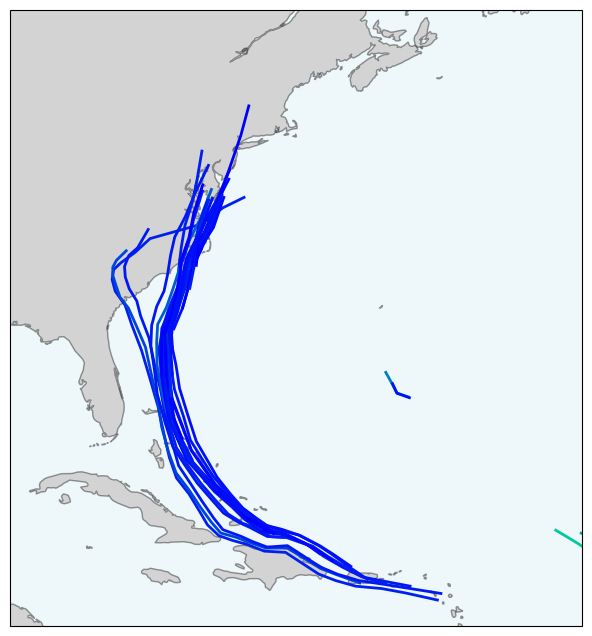

In [44]:
# Define bounding box limits
min_lat, max_lat = 15, 47
min_lon, max_lon = 275, 305

# Create figure with cartopy projection
plt.figure(figsize=(10, 8))
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)
ax = plt.axes(projection=projection)

# Add map features
ax.add_feature(cfeature.COASTLINE, alpha=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
#ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

#gl = ax.gridlines(crs=ccrs.PlateCarree(), alpha=0.5, linestyle='--', draw_labels=True)
#gl.xlabels_top = False
#gl.ylabels_left = False
#gl.xlines = True
#gl.ylines = True
#gl.xlabel_style = {'size': 10, 'color': 'gray'}
#gl.ylabel_style = {'size': 10, 'color': 'gray'}

files = sorted(glob.glob('irene_model_paths*.pt'))
#["tc_lat", "tc_lon", "tc_msl", "tc_w10m"]
for f in files:
    print(f"Load {f}")
    model_paths = torch.load(f).numpy() # dimension [batch, path, step, variable]
    model_cmap = plt.cm.winter
    for path in range(model_paths.shape[1]):
        # Get lat/lon coordinates, filtering out nans
        lats = model_paths[0, path, :, 0]
        lons = model_paths[0, path, :, 1]
        mask = ~np.isnan(lats) & ~np.isnan(lons)
        alpha=0.5
        if mask.any() and len(lons[mask]) > 2:
            color = model_cmap(path / model_paths.shape[1])
            ax.plot(
                lons[mask],
                lats[mask],
                color=color,
                markersize=4,
                linewidth=2,
                #alpha=alpha,
                label="Aurora",
                transform=ccrs.PlateCarree(),
            )
            
# Plot best track
best_cmap = plt.cm.gist_gray
ax.plot(
    storm.lon,
    storm.lat,
    color=best_cmap(storm.time.size),
    #linestyle="-.",
    marker="o",
    markersize=4,
    linewidth=2,
    label="HURR",
    transform=ccrs.PlateCarree(),
)

# Plot ERA5
era5_paths = torch.load('irene_era5_paths.pt').numpy()
era5_cmap = plt.cm.autumn
for path in range(era5_paths.shape[1]):
    # Get lat/lon coordinates, filtering out nans
    lats = era5_paths[0, path, :, 0]
    lons = era5_paths[0, path, :, 1]
    mask = ~np.isnan(lats) & ~np.isnan(lons)
    if mask.any() and len(lons[mask]) > 2:
        color = era5_cmap(path / era5_paths.shape[1])
        ax.plot(
            lons[mask],
            lats[mask],
            color=color,
            #linestyle="-.",
            marker="o",
            markersize=4,
            label="ERA5",
            transform=ccrs.PlateCarree(),
        )

# Add legend
best_patch = mpatches.Rectangle(
    (0, 0), 1, 1, fc=best_cmap(0.3), alpha=0.9, label="Best Track"
)
era5_patch = mpatches.Rectangle(
    (0, 0), 1, 1, fc=era5_cmap(0.3), alpha=0.9, label="ERA5"
)
model_patch = mpatches.Rectangle(
    (0, 0), 1, 1, fc=model_cmap(0.3), alpha=0.9, label="Aurora"
)
ax.legend(handles=[best_patch, era5_patch, model_patch], loc="upper right", title="Cyclone Tracks")

# Add ROMS grid box
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')
ax.plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='red', linewidth=1, transform=ccrs.PlateCarree()) # Bottom
ax.plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='red', linewidth=1, transform=ccrs.PlateCarree()) # Top
ax.plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='red', linewidth=1, transform=ccrs.PlateCarree()) # Left
ax.plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='red', linewidth=1, transform=ccrs.PlateCarree()) # Right

# Save figure
plt.savefig(f"Fig_cyclone_tracks_irene.png", bbox_inches="tight", dpi=300)

In [68]:
x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")

# Create empty data frame with index
df = pd.DataFrame(index=x)

# Add HURR dataset
df['lon'] = np.zeros(x.shape)
df['lat'] = np.zeros(x.shape)
df['mslp'] = np.zeros(x.shape)
df['vmax'] = np.zeros(x.shape)
for i in range(len(storm.lon)):
    if storm.time[i] in x:
        df['lon'].loc[storm.time[i]] = storm.lon[i]
        df['lat'].loc[storm.time[i]] = storm.lat[i]
        df['mslp'].loc[storm.time[i]] = storm.vars['mslp'][i]
        df['vmax'].loc[storm.time[i]] = storm.vars['vmax'][i]

# Add ERA5
era5_paths = torch.load('irene_era5_paths.pt').numpy()
tolerance = 3.0
df['lon_era5'] = np.zeros(x.shape)
df['lat_era5'] = np.zeros(x.shape)
df['mslp_era5'] = np.zeros(x.shape)
df['vmax_era5'] = np.zeros(x.shape)
for tindx in range(era5_paths.shape[2]):
    for path in range(era5_paths.shape[1]):
        # Get lat/lon coordinates, filtering out nans
        lat = era5_paths[0, path, tindx, 0]
        lon = era5_paths[0, path, tindx, 1]-360.0
        mslp = era5_paths[0, path, tindx, 2]/100.0
        vmax = era5_paths[0, path, tindx, 3]
        mask = ~np.isnan(lat) & ~np.isnan(lon)

        # Create min and max lat, lon based on observational data
        minlon = df['lon'].loc[x[tindx]]-tolerance
        maxlon = df['lon'].loc[x[tindx]]+tolerance
        minlat = df['lat'].loc[x[tindx]]-tolerance
        maxlat = df['lat'].loc[x[tindx]]+tolerance
        mask2 = lat >= minlat and lat <= maxlat and lon >= minlon and lon <= maxlon

        if mask and mask2:
            df['lon_era5'].loc[x[tindx]] = lon
            df['lat_era5'].loc[x[tindx]] = lat
            df['mslp_era5'].loc[x[tindx]] = mslp
            df['vmax_era5'].loc[x[tindx]] = vmax

# Fill gaps
df = df.replace(0.0, np.nan)
df['lon_era5'] = df['lon_era5'].interpolate(method='linear', limit_area='inside')
df['lat_era5'] = df['lat_era5'].interpolate(method='linear', limit_area='inside')
df['mslp_era5'] = df['mslp_era5'].interpolate(method='linear', limit_area='inside')
df['vmax_era5'] = df['vmax_era5'].interpolate(method='linear', limit_area='inside')

# Add Aurora
model_paths = torch.load('irene_model_paths_2011-08-22T12:00:00_30.pt').numpy()
tolerance = 3.0
df['lon_model'] = np.zeros(x.shape)
df['lat_model'] = np.zeros(x.shape)
df['mslp_model'] = np.zeros(x.shape)
df['vmax_model'] = np.zeros(x.shape)
for tindx in range(model_paths.shape[2]):
    for path in range(model_paths.shape[1]):
        # Get lat/lon coordinates, filtering out nans
        lat = model_paths[0, path, tindx, 0]
        lon = model_paths[0, path, tindx, 1]-360.0
        mslp = model_paths[0, path, tindx, 2]/100.0
        vmax = model_paths[0, path, tindx, 3]
        mask = ~np.isnan(lat) & ~np.isnan(lon)

        # Create min and max lat, lon based on observational data
        minlon = df['lon'].loc[x[tindx]]-tolerance
        maxlon = df['lon'].loc[x[tindx]]+tolerance
        minlat = df['lat'].loc[x[tindx]]-tolerance
        maxlat = df['lat'].loc[x[tindx]]+tolerance
        mask2 = lat >= minlat and lat <= maxlat and lon >= minlon and lon <= maxlon

        if mask and mask2:
            df['lon_model'].loc[x[tindx]] = lon
            df['lat_model'].loc[x[tindx]] = lat
            df['mslp_model'].loc[x[tindx]] = mslp
            df['vmax_model'].loc[x[tindx]] = vmax

print(df)

                      lon   lat    mslp   vmax   lon_era5   lat_era5  \
2011-08-21 00:00:00 -59.0  15.0  1006.0   45.0        NaN        NaN   
2011-08-21 06:00:00 -60.6  16.0  1006.0   45.0        NaN        NaN   
2011-08-21 12:00:00 -62.2  16.8  1005.0   45.0        NaN        NaN   
2011-08-21 18:00:00 -63.7  17.5   999.0   50.0        NaN        NaN   
2011-08-22 00:00:00 -65.0  17.9   993.0   60.0 -65.114708  17.880577   
2011-08-22 06:00:00 -65.9  18.2   990.0   65.0 -66.069606  18.148066   
2011-08-22 12:00:00 -67.0  18.9   989.0   70.0 -67.076367  18.829755   
2011-08-22 18:00:00 -68.0  19.3   988.0   75.0 -68.065722  19.202487   
2011-08-23 00:00:00 -68.8  19.7   981.0   80.0 -68.783256  19.677414   
2011-08-23 06:00:00 -69.7  20.1   978.0   80.0 -69.693365  20.036703   
2011-08-23 12:00:00 -70.6  20.4   978.0   80.0 -70.603474  20.395991   
2011-08-23 18:00:00 -71.2  20.7   977.0   80.0 -71.087276  20.477630   
2011-08-24 00:00:00 -71.9  21.0   969.0   80.0 -71.652141  20.66

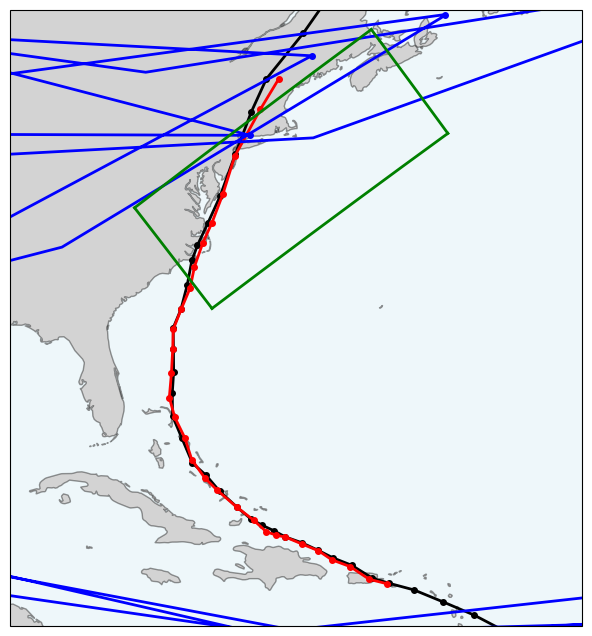

In [65]:
# Define bounding box limits
min_lat, max_lat = 15, 47
min_lon, max_lon = 275, 305

# Create figure with cartopy projection
plt.figure(figsize=(10, 8))
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)
ax = plt.axes(projection=projection)

# Add map features
ax.add_feature(cfeature.COASTLINE, alpha=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
            
# Plot best track
best_cmap = plt.cm.gist_gray
ax.plot(
    df['lon'],
    df['lat'],
    color="black",
    #linestyle="-.",
    marker="o",
    markersize=4,
    linewidth=2,
    label="HURR",
    transform=ccrs.PlateCarree(),
)

# Plot ERA5
best_cmap = plt.cm.gist_gray
ax.plot(
    df['lon_era5'],
    df['lat_era5'],
    color="red",
    marker="o",
    markersize=4,
    linewidth=2,
    label="ERA5",
    transform=ccrs.PlateCarree(),
)

# Plot Aurora
best_cmap = plt.cm.gist_gray
ax.plot(
    df['lon_model'],
    df['lat_model'],
    color="blue",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Aurora",
    transform=ccrs.PlateCarree(),
)

# Add ROMS grid box
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')
ax.plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='green', linewidth=2, transform=ccrs.PlateCarree()) # Bottom
ax.plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='green', linewidth=2, transform=ccrs.PlateCarree()) # Top
ax.plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='green', linewidth=2, transform=ccrs.PlateCarree()) # Left
ax.plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='green', linewidth=2, transform=ccrs.PlateCarree()) # Right

# Save figure
plt.savefig(f"Fig_cyclone_tracks_irene.png", bbox_inches="tight", dpi=300)

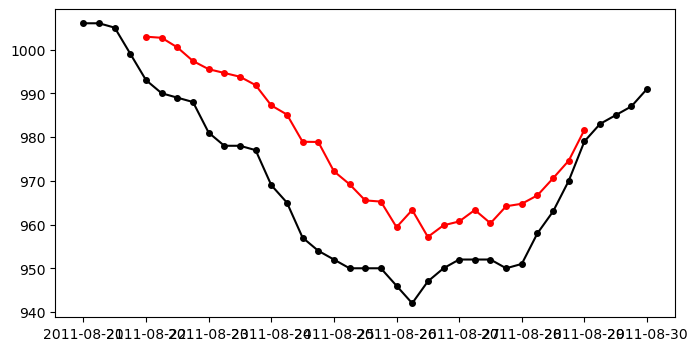

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))
#x = df.index.time
#print(x)
x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")
ax.plot(x, df['mslp'], color="black", marker="o", markersize=4, label="HURDAT2")
ax.plot(x, df['mslp_era5'], color="red", marker="o", markersize=4, label="ERA5")
#ax_y = ax.twinx()
#ax_y.plot(storm.time, storm.vars['vmax'], color="red", marker="o", markersize=4, label="HURDAT2 [VMAX]")
#ax.set_xlabel('Date')
#ax.tick_params(axis='x', labelrotation=45)
#ax.legend(ncol=2, fontsize=8, loc='upper right')
#ax_y.legend(ncol=2, fontsize=8, loc='lower right')
#ax_x = ax.twiny()
#x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")
#ax.plot(x, era5_paths[0,:,0,2], marker="o", markersize=4, label="BestTrack")

#["tc_lat", "tc_lon", "tc_msl", "tc_w10m"]
#[batch, path, step, variable]
#
#era5_paths,
#print(storm.time)
#print(storm.time.shape)
#print(era5_paths.shape)
#x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")
#print(x.shape)
#print(len(time_range))
#era5_mslp = []
#for path in range(era5_paths.shape[1]):
#    # Get lat/lon coordinates, filtering out nans
#    lats = era5_paths[0, path, :, 0]
#    lons = era5_paths[0, path, :, 1]
#    mslp = era5_paths[0, path, :, 2]
#    mask = ~np.isnan(lats) & ~np.isnan(lons)
#    if mask.any() and len(lons[mask]) > 2:
#        print(path, mslp[mask], )
#        #era5_mslp.append(mslp[mask])
#print(era5_mslp)
#x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")
#print(x.shape)
#print(len(era5_mslp))
#ax.plot(x, era5_mslp, marker="o", markersize=4, label="BestTrack")

#minlon = np.min(storm.lon)+360.0
#maxlon = np.max(storm.lon)+360.0
#minlat = np.min(storm.lat)
#maxlat = np.max(storm.lat)
#print(minlon, maxlon, minlat, maxlat)

#for tindx in range(era5_paths.shape[2]):
#    for path in range(era5_paths.shape[1]):
#        # Get lat/lon coordinates, filtering out nans
#        lat = era5_paths[0, path, tindx, 0]
#        lon = era5_paths[0, path, tindx, 1]
#        mslp = era5_paths[0, path, tindx, 2]
#        vmax = era5_paths[0, path, tindx, 3]
#        mask = True
#        if lon >= minlon and lon <= maxlon and lat >= minlat and lat <= maxlat:
#            mask = False
#        #results = [lon >= minlon and lon <= maxlon and lat >= minlat and lat <= maxlat for lat, lon in zip(lats, lons)]
#        
#        print(tindx, path, lat, lon, mslp, mask)
#    #mask = ~np.isnan(lats) & ~np.isnan(lons)


### Load datasets

**Table 1:** Detailed information about conducted simulations
| #  | Data Component | Input     | Temporal Interpolation Type | Coupling Type      | Feedback                 |
|----|----------------|-----------|-----------------------------|--------------------|--------------------------|
| r1 | CDEPS          | ERA5 (6h) | coszen                      | one-way: ATM->OCN  | No                       |
| r2 | CDEPS          | ERA5 (1h) | coszen                      | one-way: ATM->OCN  | No                       |
| r3 | CDEPS          | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r4 | CDEPS          | ERA5 (1h) | linear                      | one-way: ATM->OCN  | No                       |
| r5 | Aurora         | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r6 | Aurora         | ERA5 (6h) | linear                      | two-way: ATM<->OCN | Yes, SST from OCN to ATM |

In [233]:
# List of variables to keep
vars = {
    'Pair': [990, 1020],
    'Tair': [10, 30],
    'Uwind': [-20, 20],
    'Vwind': [-20, 20],
    'swrad': [0, 500],
    'lwrad': [-50, 100],
    'latent': [-100, 100],
    'sensible': [-100, 100]
}
var_names = list(vars.keys())

# Open datasets and merge them
ds1 = xr.open_dataset("../run_cdeps/r1/irene_his.nc")[var_names]
ds2 = xr.open_dataset("../run_cdeps/r2/irene_his.nc")[var_names]
ds3 = xr.open_dataset("../run_cdeps/r3/irene_his.nc")[var_names]
ds4 = xr.open_dataset("../run_cdeps/r4/irene_his.nc")[var_names]
ds5 = xr.open_dataset("../run/r5/irene_his.nc")[var_names]
ds6 = xr.open_dataset("../run/r6/irene_his.nc")[var_names]
ds = xr.concat([ds1, ds2, ds3, ds4, ds5, ds6], dim='run_id')

In [234]:
dsx = xr.open_dataset("../run_cdeps/r1/irene_his.nc")
dsx

<xarray.Dataset> Size: 3GB
Dimensions:          (tracer: 2, boundary: 4, s_rho: 40, s_w: 41, eta_rho: 106,
                      xi_rho: 242, eta_u: 106, xi_u: 241, eta_v: 105,
                      xi_v: 242, eta_psi: 105, xi_psi: 241, ocean_time: 42)
Coordinates:
  * s_rho            (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w              (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.05 -0.025 0.0
    lon_rho          (eta_rho, xi_rho) float64 205kB ...
    lat_rho          (eta_rho, xi_rho) float64 205kB ...
    lon_u            (eta_u, xi_u) float64 204kB ...
    lat_u            (eta_u, xi_u) float64 204kB ...
    lon_v            (eta_v, xi_v) float64 203kB ...
    lat_v            (eta_v, xi_v) float64 203kB ...
    lon_psi          (eta_psi, xi_psi) float64 202kB ...
    lat_psi          (eta_psi, xi_psi) float64 202kB ...
  * ocean_time       (ocean_time) datetime64[ns] 336B 2011-08-27T06:00:00 ......
Dimensions without coordinates: tracer, boundary, eta_rho, xi_rho, eta_u, xi_u,
                                eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/115)
    ntimes           int32 4B ...
    ndtfast          int32 4B ...
    dt               float64 8B ...
    dtfast           float64 8B ...
    dstart           datetime64[ns] 8B ...
    nHIS             int32 4B ...
    ...               ...
    evaporation      (ocean_time, eta_rho, xi_rho) float64 9MB ...
    rain             (ocean_time, eta_rho, xi_rho) float64 9MB ...
    EminusP          (ocean_time, eta_rho, xi_rho) float64 9MB ...
    swrad            (ocean_time, eta_rho, xi_rho) float64 9MB ...
    sustr            (ocean_time, eta_u, xi_u) float64 9MB ...
    svstr            (ocean_time, eta_v, xi_v) float64 9MB ...
Attributes: (12/33)
    file:              irene_his.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS history file
    title:             Hurricane Irene, 27-29 Aug 2011
    var_info:          varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.27/ofi/gnu/9.1/bin/mpif90
    compiler_flags:    -I/glade/work/turuncu/ML/envs/spack-1.0.2/var/spack/en...
    tiling:            3x4
    history:           ROMS, Version 4.3, Thursday - December 11, 2025 - 11:1...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       IRENE, ADD_FSOBC, ADD_M2OBC, ANA_BSFLUX, ANA_BTFLUX, A...

### Spatial plots for input forcing for each run

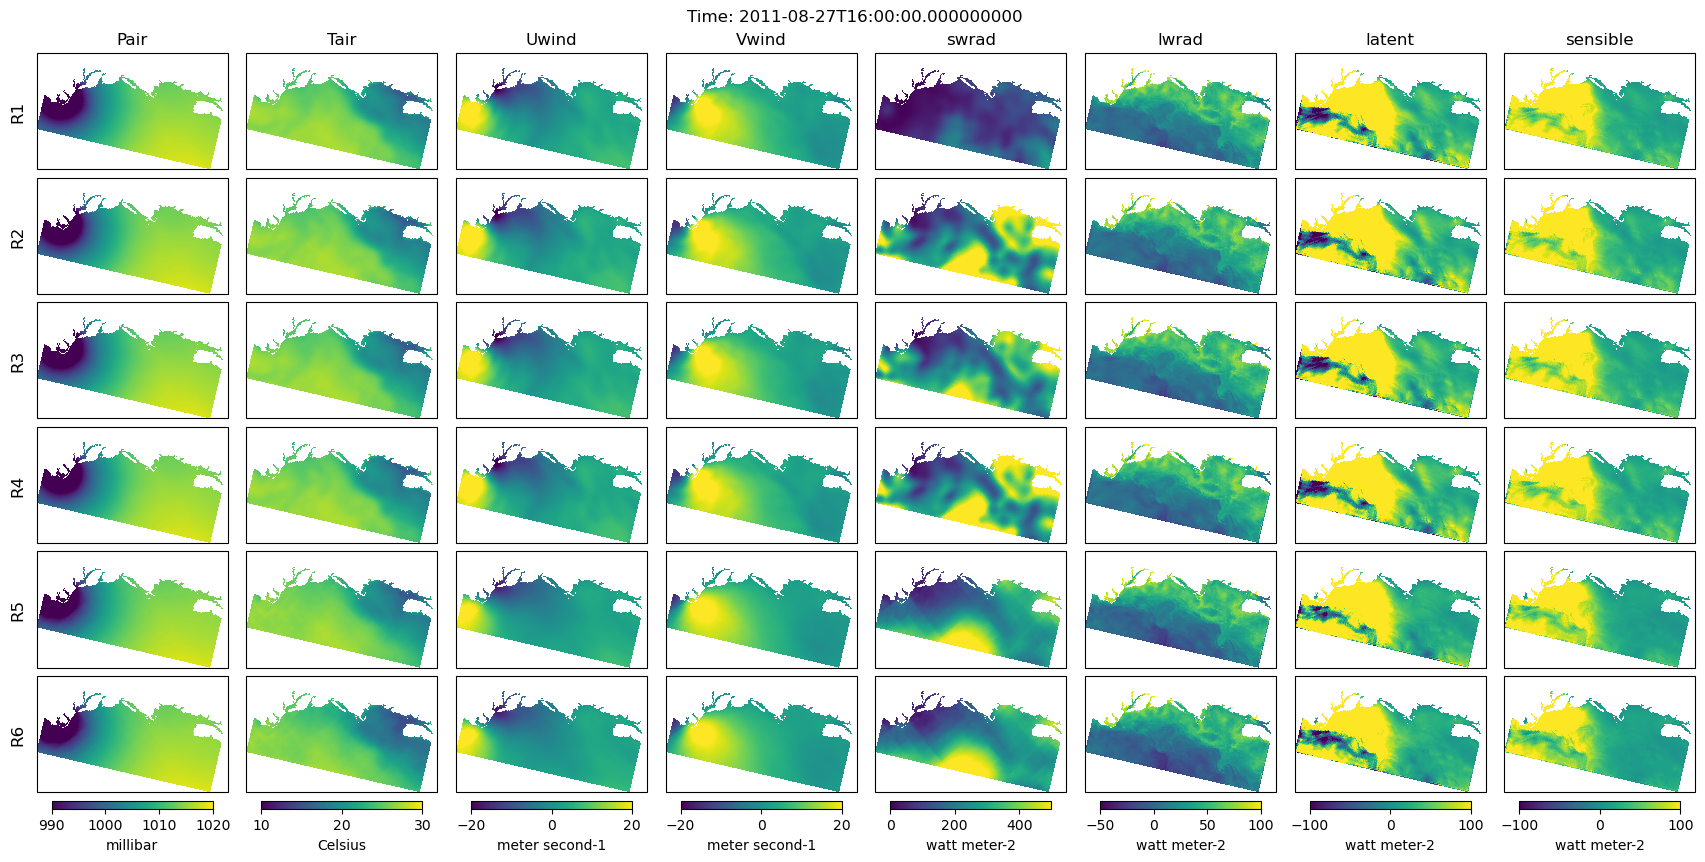

In [242]:
# Define bounding box limits
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Create figure
nrow = ds.run_id.shape[0] # number of datasets
ncol = len(var_names) # number of variables
fig, ax = plt.subplots(
    nrow, 
    ncol, 
    figsize=(17, 8.5), 
    layout='constrained', 
    subplot_kw={'projection': projection})

# Set timestep
tindx = 10

# Add figure title
fig.suptitle(f"Time: {ds[var_name].isel(ocean_time=tindx).ocean_time.values}", fontsize=12)

# Add sub plots
im = []
for icol in range(ncol):
    for irow in range(nrow):
        var_name = var_names[icol]
        vmin, vmax = vars[var_name]
        im.append(ds[var_name].isel(run_id=irow, ocean_time=10).plot(ax=ax[irow,icol], transform=ccrs.LambertConformal(), vmin=vmin, vmax=vmax, cmap='viridis', add_colorbar=False))
        if irow == 0:
            ax[irow,icol].set_title(var_name)
        else:
            ax[irow,icol].set_title("")
        if icol == 0:
            ax[irow,icol].text(-0.1, 0.5, f"R{irow+1}", transform=ax[irow,icol].transAxes, rotation=90, ha='center', va='center', fontsize=12)
        ax[irow,icol].coastlines()
    fig.colorbar(im[-1], ax=ax[:,icol], location='bottom', pad=0.01, aspect=20, shrink=0.8, label=ds[var_name].units)

### Spatial plot from ROMS

In [316]:
var = "zeta"
ds5 = xr.open_dataset("../run/r5/irene_his.nc").isel(s_rho=-1)[[var]]
ds6 = xr.open_dataset("../run/r6/irene_his.nc").isel(s_rho=-1)[[var]]

Text(0.5, 1.0, '')

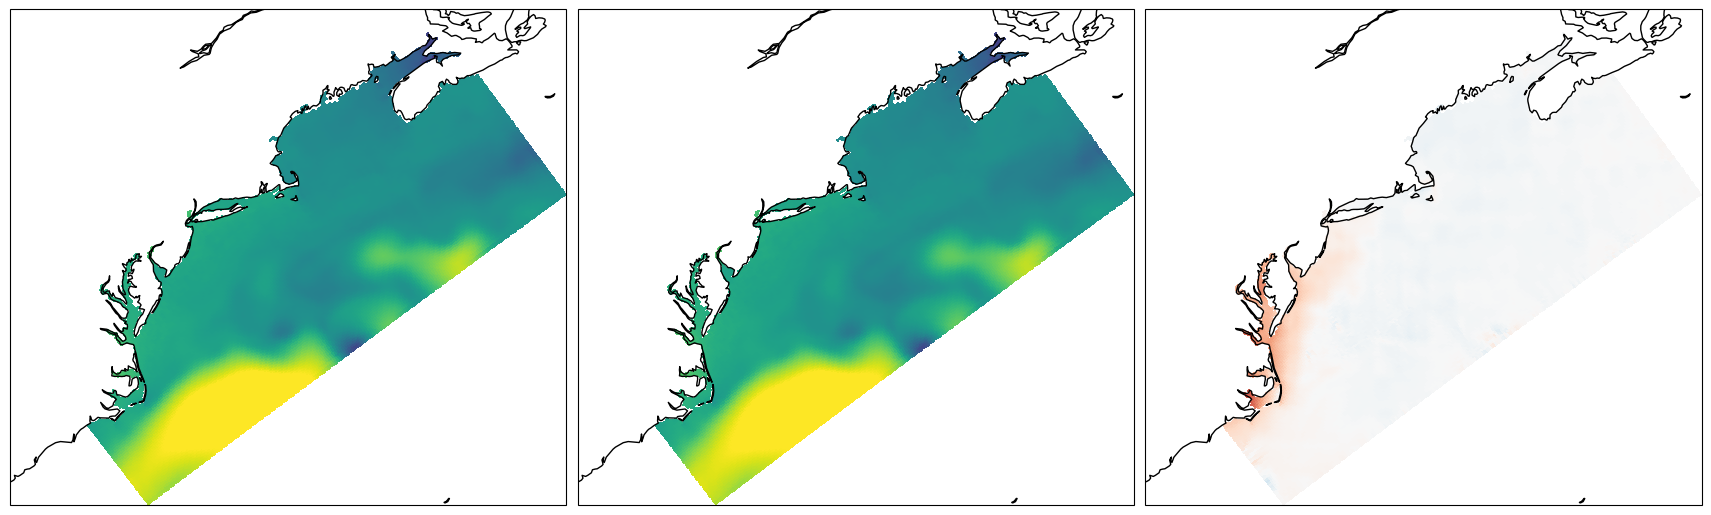

In [319]:
fig, ax = plt.subplots(
    1, 
    3, 
    figsize=(17, 8.5), 
    layout='constrained', 
    subplot_kw={'projection': projection})

data1 = ds5[var].mean(dim='ocean_time')
plot1 = data1.plot(
    x="lon_rho", 
    y="lat_rho",
    ax=ax[0],
    transform=ccrs.PlateCarree(), 
    vmin=-1, 
    vmax=1,
    cmap='viridis',
    add_colorbar=False)
ax[0].coastlines(resolution='50m', color='black', linewidth=1)
ax[0].set_title("")

data2 = ds6[var].mean(dim='ocean_time')
plot2 = data2.plot(
    x="lon_rho", 
    y="lat_rho",
    ax=ax[1],
    transform=ccrs.PlateCarree(), 
    vmin=-1, 
    vmax=1,
    cmap='viridis',
    add_colorbar=False)
ax[1].coastlines(resolution='50m', color='black', linewidth=1)
ax[1].set_title("")

diff = data2-data1
plot3 = diff.plot(
    x="lon_rho", 
    y="lat_rho",
    ax=ax[2],
    transform=ccrs.PlateCarree(), 
    vmin=-0.05, 
    vmax=0.05,
    cmap='RdBu_r',
    add_colorbar=False)
ax[2].coastlines(resolution='50m', color='black', linewidth=1)
ax[2].set_title("")

### 

In [321]:
ds_o = xr.open_dataset('irene_sst_20110827.nc4')

In [322]:
ds_o

<xarray.Dataset> Size: 247kB
Dimensions:   (Location: 61739, nvars: 1, survey: 34)
Coordinates:
  * Location  (Location) int32 247kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
  * nvars     (nvars) int32 4B 0
  * survey    (survey) int32 136B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
Data variables:
    *empty*
Attributes:
    _ioda_layout:          ObsGroup
    _ioda_layout_version:  3
    odb_version:           1
    date_time:             2011082700.0
    datetimeReference:     2011-08-27T00:00:00Z
    description:           Native ROMS 4D-Var observations file converted to ...
    sourceFiles:           irene_obs_20110827.nc
    history:               Created from Matlab script: create_ioda_obs on Fri...

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
im = ax_local.imshow(data, cmap='plasma', aspect=4)

### Atmospheric Analyses